In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#  Unzip the yolov8 version of cap dataset downloaded from Roboflow () 

In [ ]:
!unzip "/content/drive/MyDrive/dataset/yolov8_cap_dataset/bottle_cap_defect_yolov8.zip" -d "/content/drive/MyDrive/datase/yolov8_cap_dataset/"

In [3]:
import os
HOME = os.getcwd()
print(HOME)

/content


# Install and import Libraries

In [13]:
# Pip install method (recommended)

!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 44.3/112.6 GB disk)


In [17]:
pip install -U numpy ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 113.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 73.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.2.103
    Uninstalling ultralytics-8.2.103:
      Successfully uninstalled ultralytics-8.2.103
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.2 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.2 which is incompatib

# Train

In [ ]:
from ultralytics import YOLO

# Load pre-trained YOLOv8 model
model = YOLO('yolov8s.pt')

# Fine-tune on custom dataset (Roboflow YOLO format)
model.train(
    data="/content/drive/MyDrive/dataset/yolov8_cap_dataset/data.yaml",  # Path to dataset config
    epochs=10,
    imgsz=640,
    batch=16,
    project="/content/drive/MyDrive/dataset/models",  # Save here
    name="bottle-cap-v8",
    exist_ok=True
)


Ultralytics 8.3.175 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/dataset/Ramak/yolov8_cap_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=bottle-cap-v8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspe

train: Scanning /content/drive/MyDrive/dataset/Ramak/yolov8_cap_dataset/train/labels.cache... 1503 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1503/1503 [00:00<?, ?it/s]

WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 6, len(boxes) = 1629. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 41.2±19.2 MB/s, size: 128.9 KB)


val: Scanning /content/drive/MyDrive/dataset/Ramak/yolov8_cap_dataset/valid/labels.cache... 92 images, 0 backgrounds, 0 corrupt: 100%|██████████| 92/92 [00:00<?, ?it/s]


...

                   all         92         94      0.857      0.896      0.882       0.87



10 epochs completed in 0.132 hours.
Optimizer stripped from /content/drive/MyDrive/dataset/Ramak/models/bottle-cap-v8/weights/last.pt, 22.5MB
Optimizer stripped from /content/drive/MyDrive/dataset/Ramak/models/bottle-cap-v8/weights/best.pt, 22.5MB

Validating /content/drive/MyDrive/dataset/Ramak/models/bottle-cap-v8/weights/best.pt...
Ultralytics 8.3.175 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  1.60it/s]


                   all         92         94      0.857      0.896      0.883       0.87
                defect         51         51      0.969       0.98      0.993      0.957
                  good         19         19      0.965          1      0.995      0.989
              loos-cap          4          4      0.486        0.5      0.435      0.415
                no-cap          7          7      0.918          1      0.995      0.995
          ring-missing         13         13      0.949          1      0.995      0.995
Speed: 0.5ms preprocess, 3.7ms inference, 0.0ms loss, 5.5ms postprocess per image
Results saved to /content/drive/MyDrive/dataset/Ramak/models/bottle-cap-v8


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bab7d027b10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

# Evaluation

In [ ]:
metrics = model.val(
    data='/content/drive/MyDrive/dataset/yolov8_cap_dataset/data.yaml',
    split='test',
    imgsz=640,
    batch=16
)

print(metrics)

Ultralytics 8.3.175 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 27.1±5.5 MB/s, size: 132.3 KB)


val: Scanning /content/drive/MyDrive/dataset/Ramak/yolov8_cap_dataset/test/labels... 92 images, 0 backgrounds, 0 corrupt: 100%|██████████| 92/92 [00:00<00:00, 106.32it/s]

val: New cache created: /content/drive/MyDrive/dataset/Ramak/yolov8_cap_dataset/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:02<00:00,  2.16it/s]


                   all         92         94      0.953       0.97      0.975      0.951
                defect         45         45      0.999      0.956      0.987      0.981
                  good         18         18      0.993          1      0.995       0.99
              loos-cap          7          7      0.921          1      0.995      0.995
                no-cap          5          5      0.961          1      0.995      0.911
          ring-missing         19         19      0.893      0.895      0.903      0.878
Speed: 3.1ms preprocess, 7.3ms inference, 0.0ms loss, 4.0ms postprocess per image
Results saved to /content/drive/MyDrive/dataset/Ramak/models/bottle-cap-v8
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bac327f3fd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)

In [8]:
!pip install -q supervision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 6.8 MB/s eta 0:00:00


In [10]:
import supervision as sv

In [ ]:
from supervision.metrics import MeanAveragePrecision

model = YOLO(f'/content/drive/MyDrive/dataset/models/bottle-cap-v8/weights/best.pt')

predictions = []
targets = []

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"/content/drive/MyDrive/dataset/yolov8_cap_dataset/test/images",
    annotations_directory_path=f"/content/drive/MyDrive/dataset/yolov8_cap_dataset/test/labels",
    data_yaml_path=f"/content/drive/MyDrive/dataset/yolov8_cap_dataset/data.yaml"
)

for _, image, target in ds:
    results = model(image, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)

    predictions.append(detections)
    targets.append(target)

map = MeanAveragePrecision().update(predictions, targets).compute()

In [12]:
print("mAP 50:95", map.map50_95)
print("mAP 50", map.map50)
print("mAP 75", map.map75)

mAP 50:95 0.9292894714572671
mAP 50 0.957998957790516
mAP 75 0.957998957790516


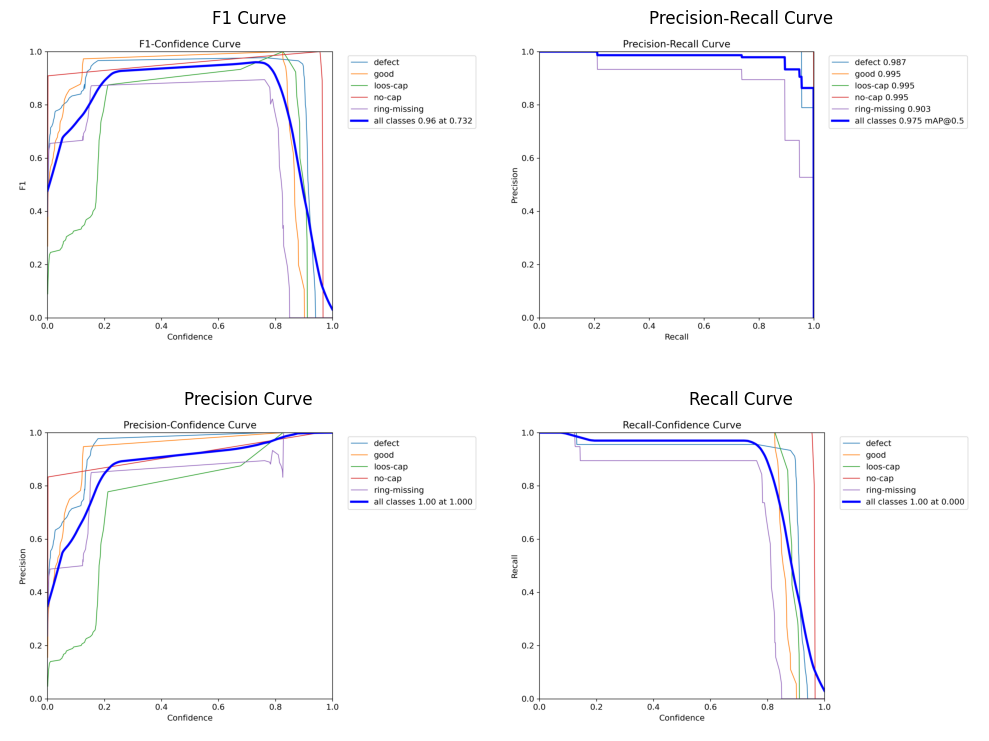

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Replace this with the actual path to your image
image_path_f1 = '/content/drive/MyDrive/dataset/models/bottle-cap-v8/BoxF1_curve.png'
image_path_pr = '/content/drive/MyDrive/dataset/models/bottle-cap-v8/BoxPR_curve.png'
image_path_p = '/content/drive/MyDrive/dataset/models/bottle-cap-v8/BoxP_curve.png'
image_path_r = '/content/drive/MyDrive/dataset/models/bottle-cap-v8/BoxR_curve.png'
image_path_cm = '/content/drive/MyDrive/dataset/models/bottle-cap-v8/confusion_matrix_normalized.png'


# Load images using PIL
images = [
    (Image.open(image_path_f1), 'F1 Curve'),
    (Image.open(image_path_pr), 'Precision-Recall Curve'),
    (Image.open(image_path_p), 'Precision Curve'),
    (Image.open(image_path_r), 'Recall Curve')
]

# Plot in a 2x3 grid
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, (img, title) in enumerate(images):
    ax = axes[i // 2, i % 2]
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()



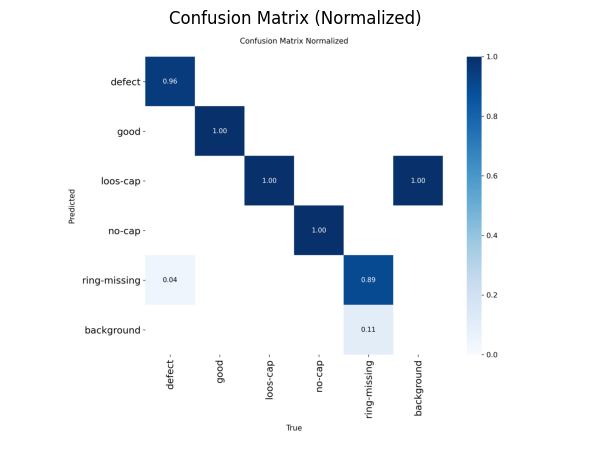

In [14]:
# Load the image
cm_image = Image.open(image_path_cm)

# Display in a separate figure
plt.figure(figsize=(6, 6))
plt.imshow(cm_image)
plt.title("Confusion Matrix (Normalized)")
plt.axis('off')
plt.tight_layout()
plt.show()

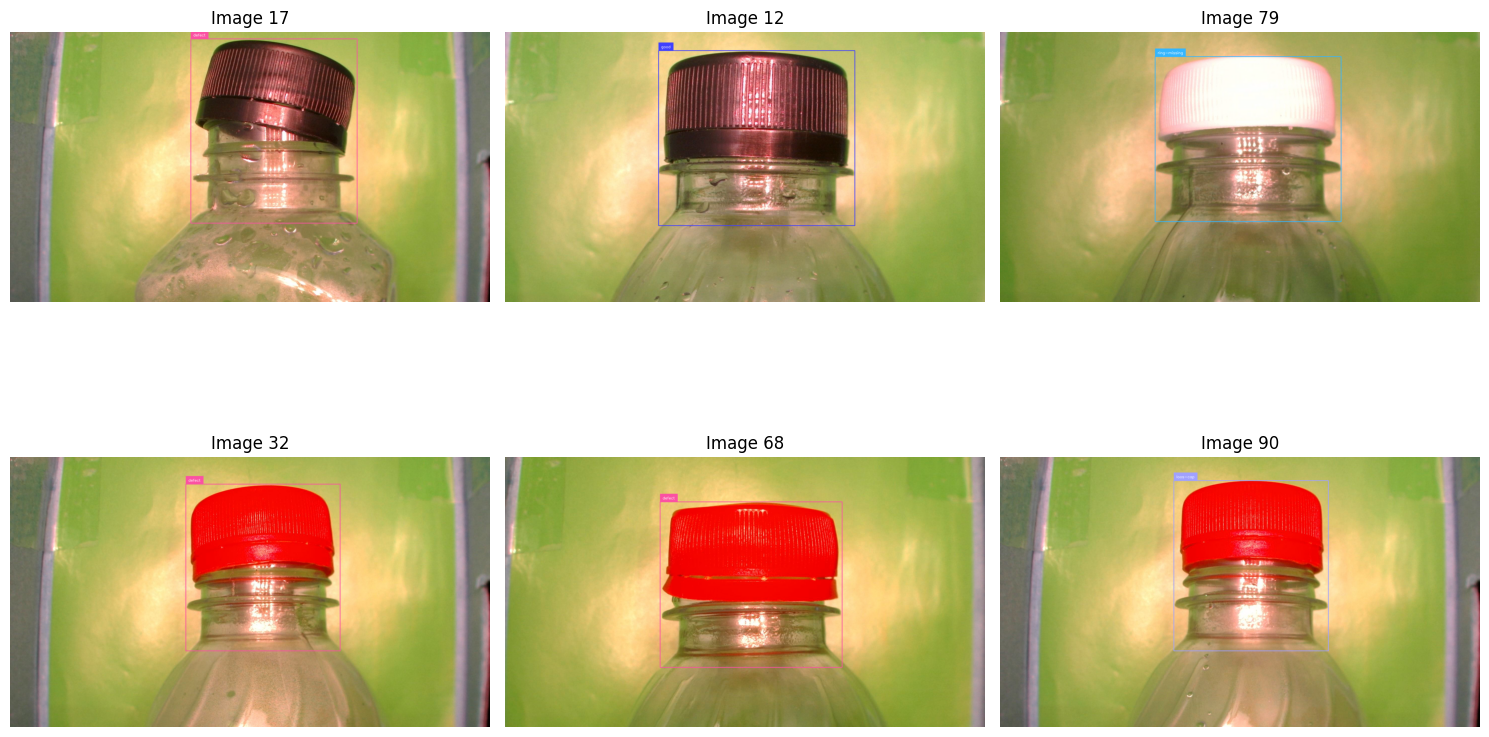

In [15]:
import random
import matplotlib.pyplot as plt
import supervision as sv

# Initialize annotators once
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

# How many random images to show
num_images = 6
rows, cols = 2, 3  # Grid shape for 6 images

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))

for ax in axes.flatten():
    i = random.randint(0, len(ds) - 1)
    image_path, image, target = ds[i]

    # Run detection
    results = model(image, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results).with_nms()

    # Annotate image
    annotated_image = image.copy()
    annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

    # Show the annotated image
    ax.imshow(annotated_image)
    ax.set_title(f"Image {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()
